<a href="https://colab.research.google.com/github/yesayaalvin/crane-safety-digital-twin/blob/main/crane_telemetry_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ingesting telemetry dataset directly from GitHub: 'https://raw.githubusercontent.com/yesayaalvin/crane-safety-digital-twin/main/crane_telemetry_log.csv'


/tmp/ipykernel_3748/2058424147.py:211: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


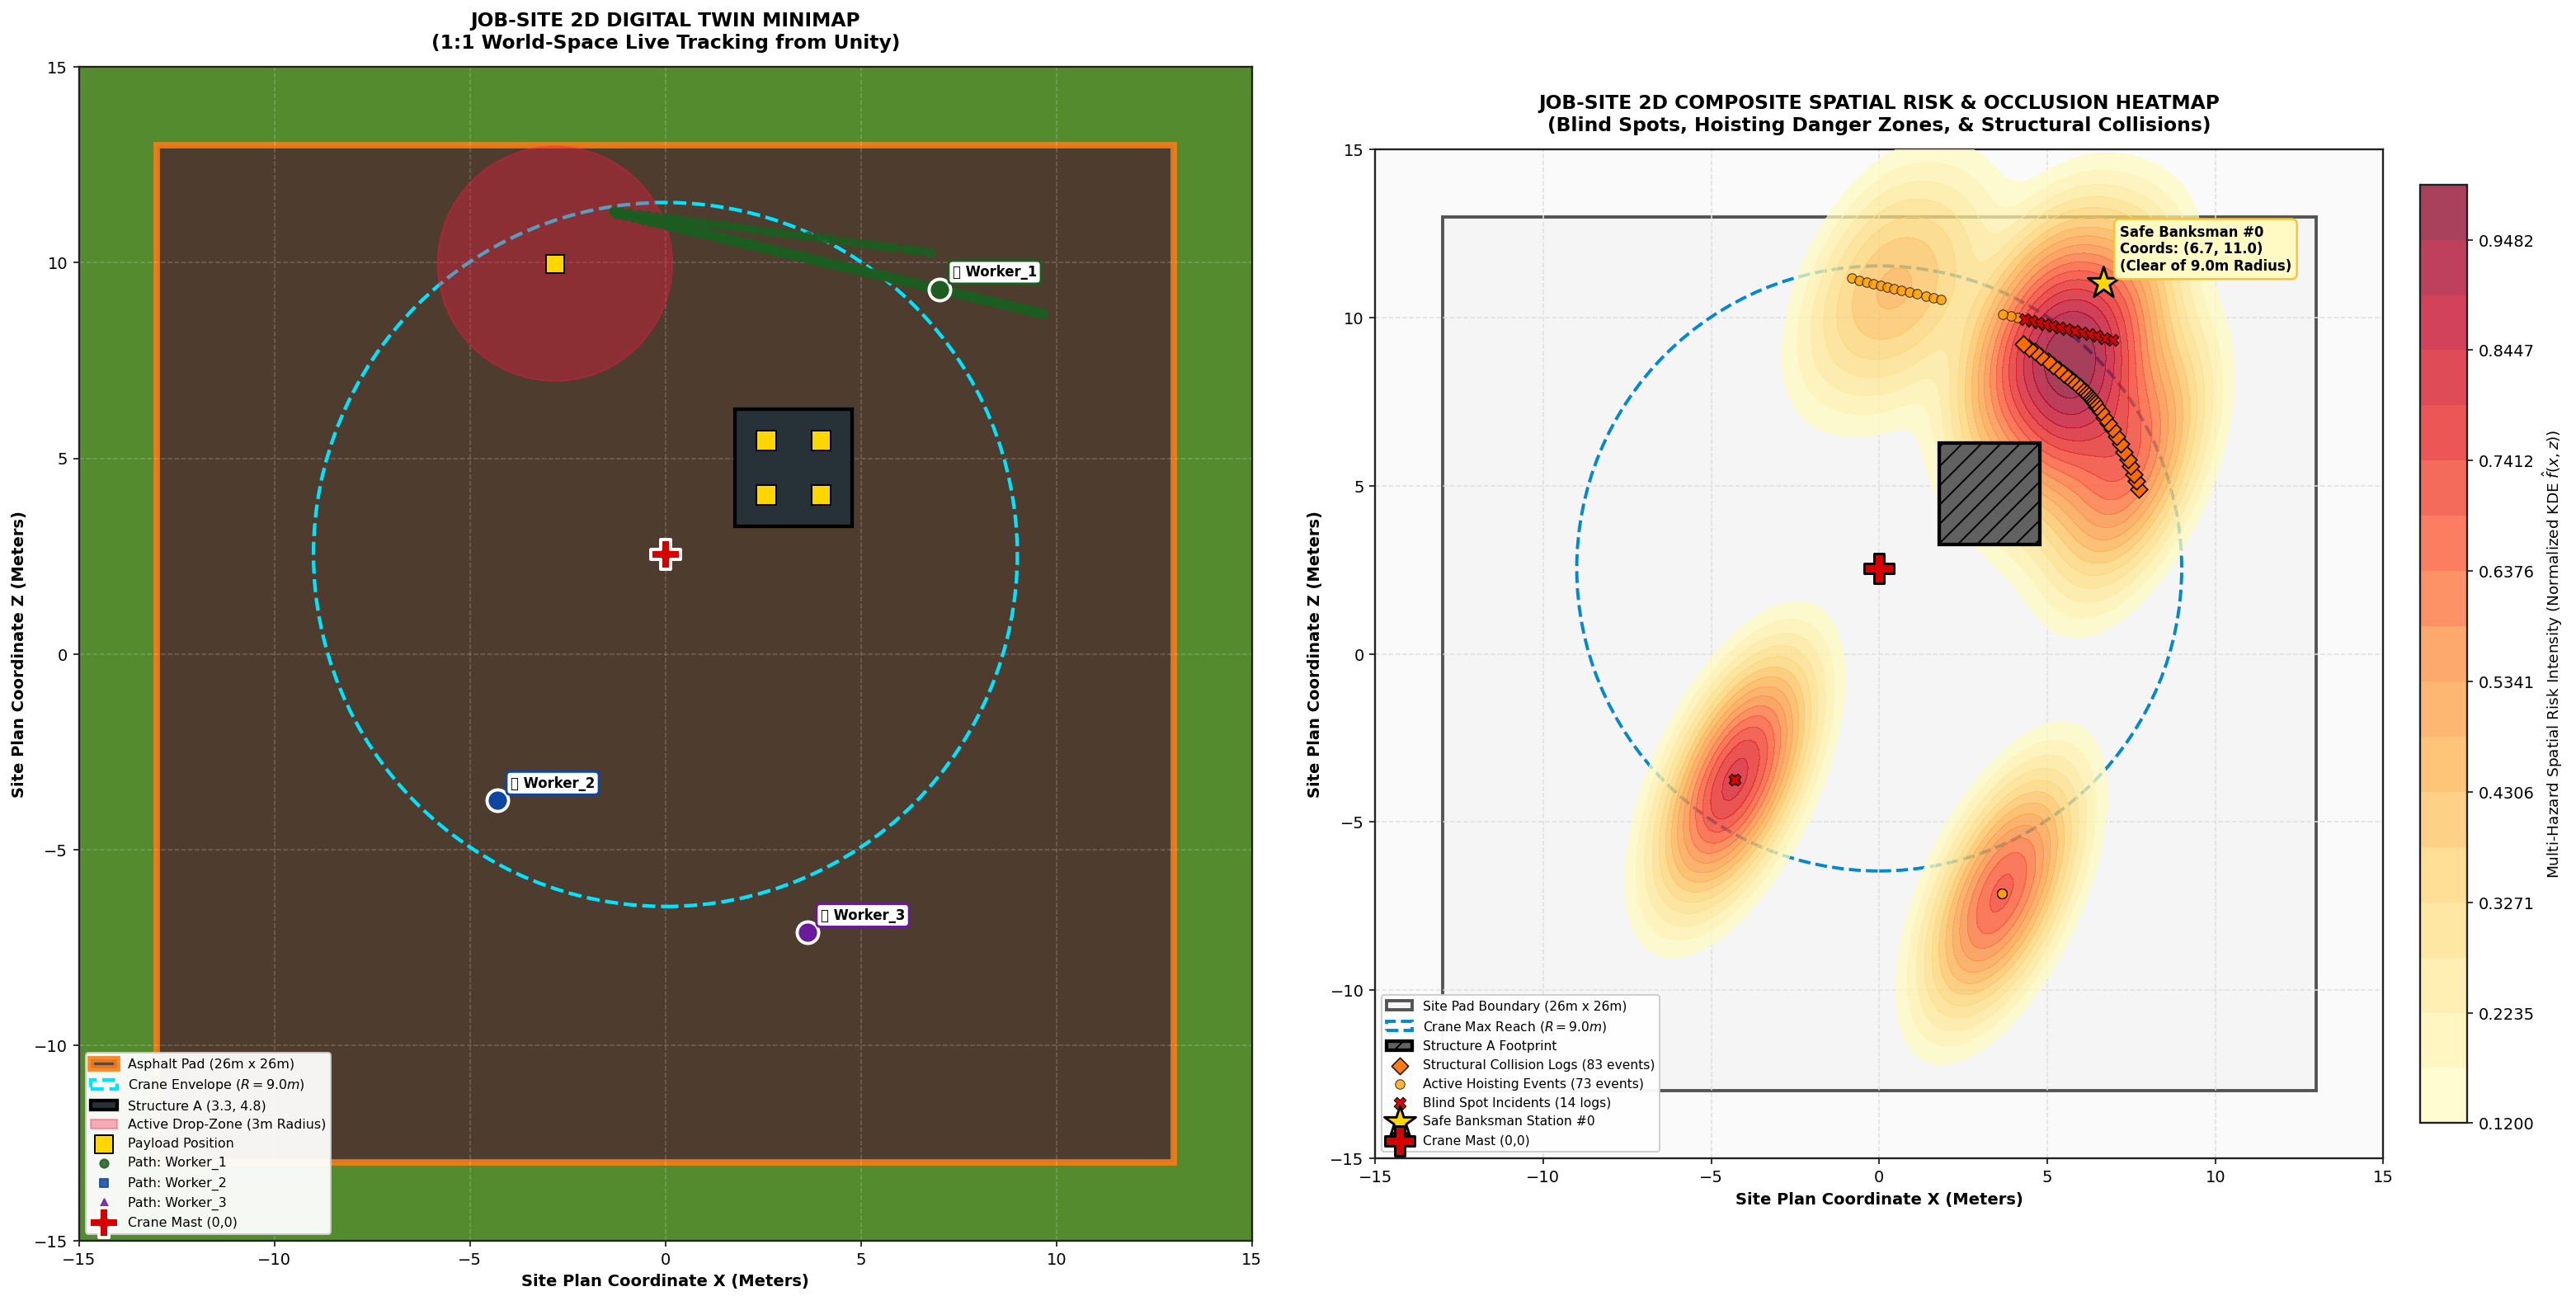

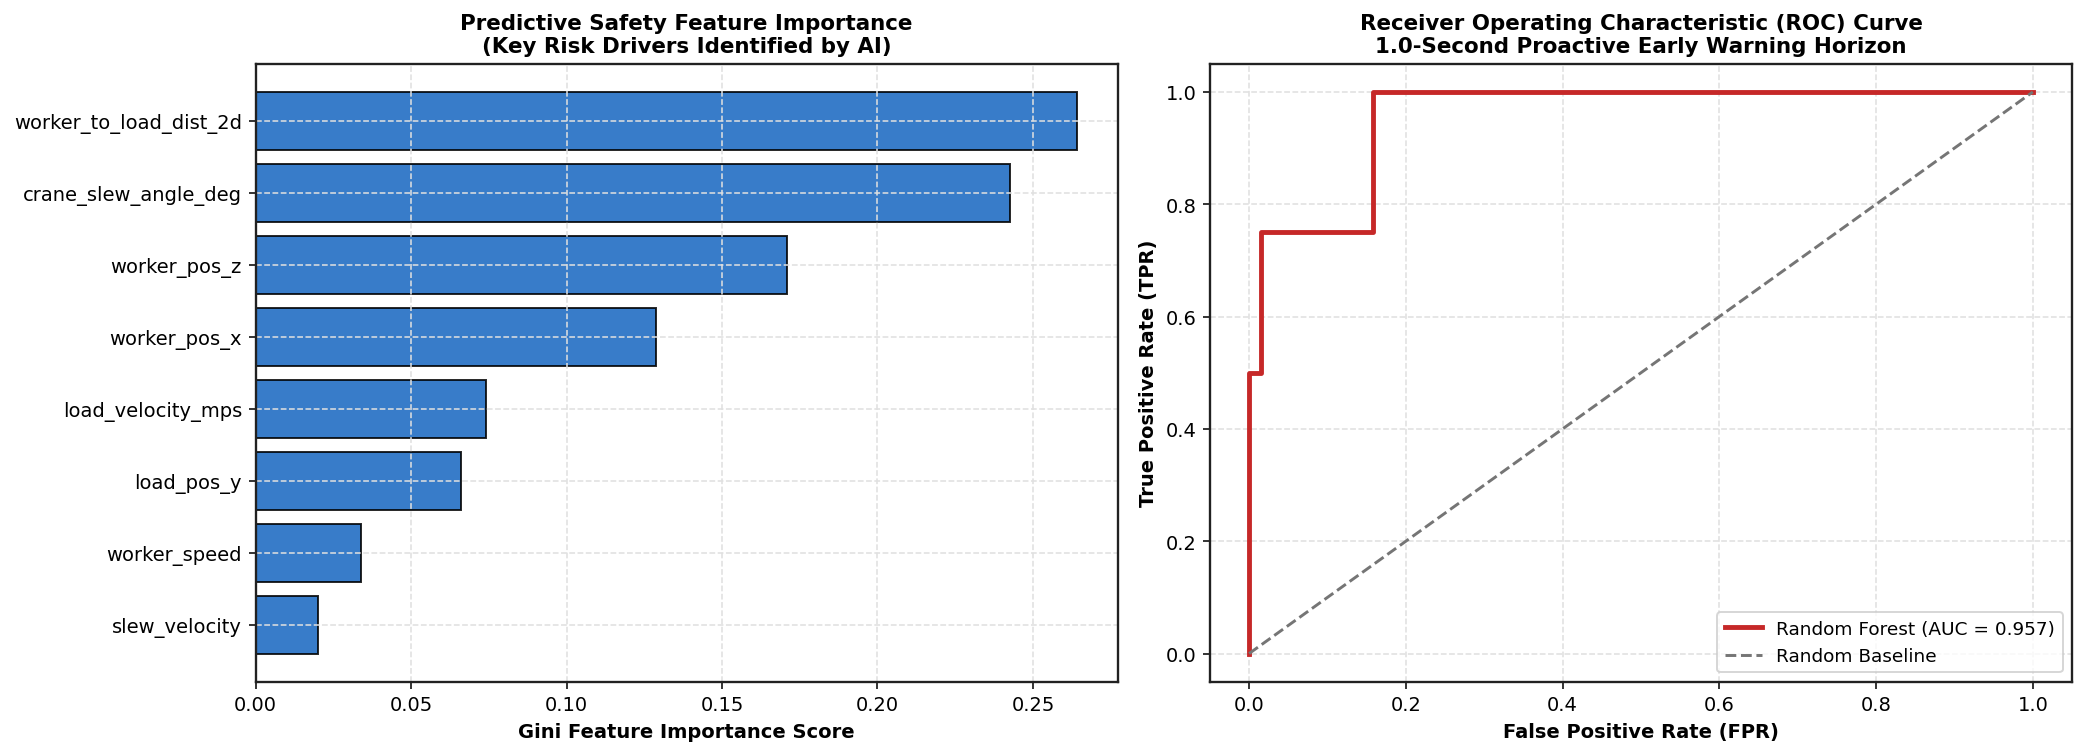

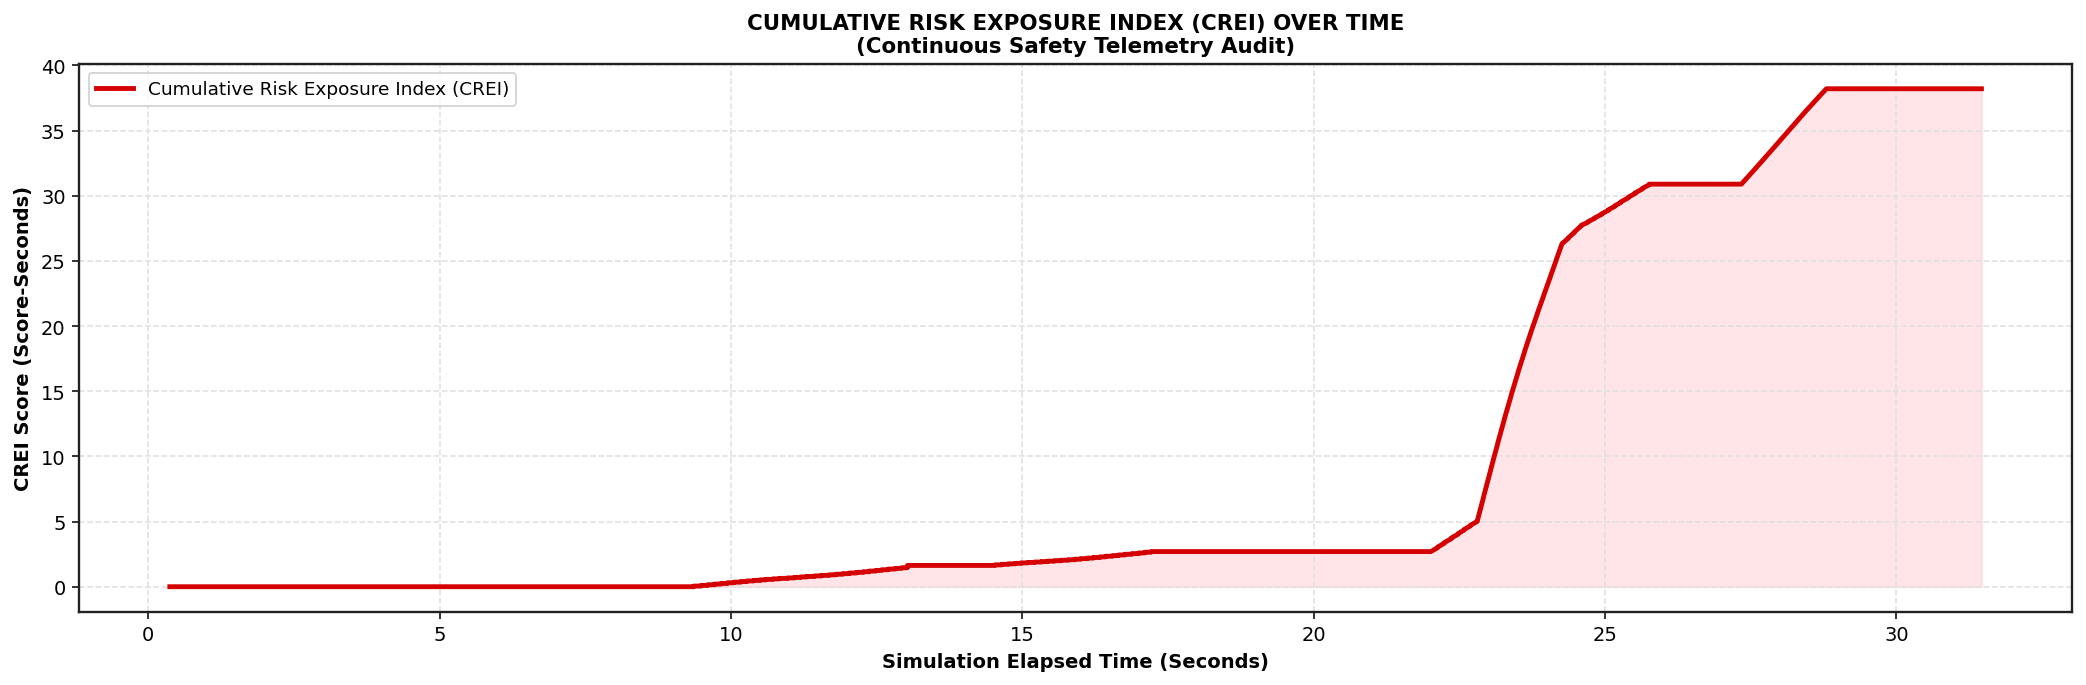


TELEMETRY & SPATIAL SAFETY VALIDATION SUMMARY:
1. Status Breakdown Across All Monitored Frames:
   • SAFE                  : 79.39%
   • STRUCTURAL_HAZARD     : 10.06%
   • DANGER_ZONE           :  8.85%
   • CRITICAL_BLINDSPOT    :  1.70%

2. Crane Radius Verification  : 9.00m (Strictly inside 26m x 26m Pad)
3. Personnel Monitored        : 3 Workers (Worker_1, Worker_2, Worker_3)
4. Structural Hazard Logs     : 83 events recorded
5. Critical Blind Spot Logs   : 14 events recorded
6. Predictive Model Accuracy  : 0.957 ROC-AUC Score


In [3]:
"""
Spatial Telemetry Analytics & Predictive Machine Learning for Tower Crane Operations.

Author: Yesaya Alvin Kriscahyadi
M.Sc. Data Science | B.Eng. Civil Engineering
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Matplotlib formatting configuration
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#212121'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.color'] = '#E0E0E0'
plt.rcParams['grid.linestyle'] = '--'

# ------------------------------------------------------------------------------
# 1. DATA INGESTION (AUTOMATIC GITHUB LOADER FOR GOOGLE COLAB)
# ------------------------------------------------------------------------------
RAW_GITHUB_CSV = "https://raw.githubusercontent.com/yesayaalvin/crane-safety-digital-twin/main/crane_telemetry_log.csv"

if os.path.exists("crane_telemetry_log.csv"):
    target_csv = "crane_telemetry_log.csv"
    print(f"Ingesting local telemetry dataset: '{target_csv}'")
else:
    target_csv = RAW_GITHUB_CSV
    print(f"Ingesting telemetry dataset directly from GitHub: '{target_csv}'")

df = pd.read_csv(target_csv)

num_cols = ['trolley_pos_x', 'trolley_pos_z', 'load_pos_x', 'load_pos_y', 'load_pos_z',
            'worker_pos_x', 'worker_pos_z', 'worker_to_load_dist_2d', 'load_velocity_mps',
            'crane_slew_angle_deg', 'sim_time_elapsed_sec']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

# ------------------------------------------------------------------------------
# 2. SITE GEOMETRY EXTRACTION
# ------------------------------------------------------------------------------
mast_x = df['crane_mast_x'].iloc[0] if 'crane_mast_x' in df.columns else 0.0
mast_z = df['crane_mast_z'].iloc[0] if 'crane_mast_z' in df.columns else 0.0

load_dist = np.sqrt((df['load_pos_x'] - mast_x)**2 + (df['load_pos_z'] - mast_z)**2)
crane_rad = max(9.0, float(load_dist.max()))
pad_size = float(df['site_pad_size'].iloc[0]) if 'site_pad_size' in df.columns else 26.0
half_pad = pad_size / 2.0

bldg_cx = float(df['bldg_world_center_x'].iloc[0]) if 'bldg_world_center_x' in df.columns else 4.07
bldg_cz = float(df['bldg_world_center_z'].iloc[0]) if 'bldg_world_center_z' in df.columns else 6.29
bldg_sx = float(df['bldg_world_size_x'].iloc[0]) if 'bldg_world_size_x' in df.columns else 3.0
bldg_sz = float(df['bldg_world_size_z'].iloc[0]) if 'bldg_world_size_z' in df.columns else 3.0
drop_radius = float(df['load_danger_radius'].iloc[0]) if 'load_danger_radius' in df.columns else 3.0

blind_df = df[df['safety_status_label'] == 'CRITICAL_BLINDSPOT'].copy()
danger_df = df[df['safety_status_label'] == 'DANGER_ZONE'].copy()
struct_df = df[df['safety_status_label'] == 'STRUCTURAL_HAZARD'].copy()

# ------------------------------------------------------------------------------
# 3. FIGURE 1: DUAL-VIEW SPATIAL RECONSTRUCTION & COMPOSITE RISK HEATMAP
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 11), dpi=140)

worker_colors = {'Worker_1': '#1B5E20', 'Worker_2': '#0D47A1', 'Worker_3': '#6A1B9A',
                 'Capsule': '#1B5E20', 'Capsule (1)': '#0D47A1', 'Capsule (2)': '#6A1B9A'}
worker_markers = {'Worker_1': 'o', 'Worker_2': 's', 'Worker_3': '^',
                  'Capsule': 'o', 'Capsule (1)': 's', 'Capsule (2)': '^'}

# Panel 1: Digital Twin Minimap
ax1.set_facecolor('#558B2F')
ax1.add_patch(patches.Rectangle((-half_pad, -half_pad), pad_size, pad_size,
                                linewidth=4.0, edgecolor='#F57F17', facecolor='#4E342E', alpha=0.9,
                                label=f'Asphalt Pad ({pad_size:.0f}m x {pad_size:.0f}m)', zorder=1))
ax1.add_patch(plt.Circle((mast_x, mast_z), crane_rad, color='#00E5FF', fill=False,
                         linestyle='--', linewidth=2.2, label=f'Crane Envelope ($R={crane_rad:.1f}m$)', zorder=2))
ax1.add_patch(patches.Rectangle((bldg_cx - bldg_sx/2, bldg_cz - bldg_sz/2), bldg_sx, bldg_sz,
                                linewidth=2.2, edgecolor='black', facecolor='#263238', alpha=1.0,
                                label=f'Structure A ({bldg_cx:.1f}, {bldg_cz:.1f})', zorder=4))

# Structure Windows
for wx in [bldg_cx - 0.7, bldg_cx + 0.7]:
    for wz in [bldg_cz - 0.7, bldg_cz + 0.7]:
        ax1.add_patch(patches.Rectangle((wx - 0.25, wz - 0.25), 0.5, 0.5, facecolor='#FFD600', edgecolor='black', zorder=5))

latest_load_x = df['load_pos_x'].iloc[-1]
latest_load_z = df['load_pos_z'].iloc[-1]
ax1.add_patch(plt.Circle((latest_load_x, latest_load_z), drop_radius, color='#FF1744', fill=True, alpha=0.35,
                         label=f'Active Drop-Zone ({drop_radius:.0f}m Radius)', zorder=6))
ax1.scatter(latest_load_x, latest_load_z, color='#FFD600', marker='s', s=120, edgecolors='black', label='Payload Position', zorder=7)

for wid, w_group in df.groupby('worker_id'):
    c = worker_colors.get(wid, '#E65100')
    m = worker_markers.get(wid, 'o')
    ax1.plot(w_group['worker_pos_x'], w_group['worker_pos_z'], color=c, alpha=0.75, linewidth=2.5, zorder=8)
    ax1.scatter(w_group['worker_pos_x'], w_group['worker_pos_z'], color=c, marker=m, s=28, alpha=0.85, label=f'Path: {wid}', zorder=9)

    end_x, end_z = w_group['worker_pos_x'].iloc[-1], w_group['worker_pos_z'].iloc[-1]
    ax1.scatter(end_x, end_z, color=c, s=180, edgecolors='white', linewidth=2.0, zorder=10)
    ax1.annotate(f"📍 {wid}", (end_x, end_z), textcoords="offset points", xytext=(8, 8),
                 bbox=dict(boxstyle="round,pad=0.3", fc="#FFFFFF", ec=c, lw=1.5), fontsize=8.5, fontweight='bold', zorder=11)

ax1.scatter(mast_x, mast_z, color='#D50000', s=350, marker='P', edgecolors='white', linewidth=2.0, label='Crane Mast (0,0)', zorder=12)
ax1.set_title("JOB-SITE 2D DIGITAL TWIN MINIMAP\n(1:1 World-Space Live Tracking from Unity)", fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel("Site Plan Coordinate X (Meters)", fontsize=10, fontweight='bold')
ax1.set_ylabel("Site Plan Coordinate Z (Meters)", fontsize=10, fontweight='bold')
ax1.set_xlim(-15.0, 15.0)
ax1.set_ylim(-15.0, 15.0)
ax1.set_aspect('equal')
ax1.grid(True, color='#FFFFFF', alpha=0.2)
ax1.legend(loc='lower left', framealpha=0.95, fontsize=8.2)

# Panel 2: Spatial Risk Heatmap & Multi-Hazard Analysis
ax2.set_facecolor('#FAFAFA')
ax2.add_patch(patches.Rectangle((-half_pad, -half_pad), pad_size, pad_size,
                                linewidth=2.0, edgecolor='#424242', facecolor='#F5F5F5', alpha=0.9,
                                label='Site Pad Boundary (26m x 26m)', zorder=1))
ax2.add_patch(plt.Circle((mast_x, mast_z), crane_rad, color='#0288D1', fill=False,
                         linestyle='--', linewidth=2.0, label=f'Crane Max Reach ($R={crane_rad:.1f}m$)', zorder=2))
ax2.add_patch(patches.Rectangle((bldg_cx - bldg_sx/2, bldg_cz - bldg_sz/2), bldg_sx, bldg_sz,
                                linewidth=2.2, edgecolor='black', facecolor='#616161', hatch='//',
                                label='Structure A Footprint', zorder=5))

risk_pts_x = []
risk_pts_z = []
if len(blind_df) > 0:
    for _ in range(10):
        risk_pts_x.extend(blind_df['worker_pos_x'].values)
        risk_pts_z.extend(blind_df['worker_pos_z'].values)
if len(danger_df) > 0:
    for _ in range(4):
        risk_pts_x.extend(danger_df['worker_pos_x'].values)
        risk_pts_z.extend(danger_df['worker_pos_z'].values)
if len(struct_df) > 0:
    for _ in range(4):
        risk_pts_x.extend(struct_df['load_pos_x'].values)
        risk_pts_z.extend(struct_df['load_pos_z'].values)

if len(risk_pts_x) >= 10:
    grid_x, grid_z = np.mgrid[-15:15:200j, -15:15:200j]
    positions = np.vstack([grid_x.ravel(), grid_z.ravel()])
    values = np.vstack([risk_pts_x, risk_pts_z])
    values += np.random.normal(0, 1e-4, values.shape)
    kernel = gaussian_kde(values, bw_method=0.28)
    density = np.reshape(kernel(positions).T, grid_x.shape)
    norm_density = (density - density.min()) / (density.max() - density.min() + 1e-6)
    vivid_density = np.power(norm_density, 0.45)

    cf = ax2.contourf(grid_x, grid_z, vivid_density, levels=np.linspace(0.12, 1.0, 18),
                      cmap='YlOrRd', alpha=0.75, zorder=3)
    cbar = plt.colorbar(cf, ax=ax2, shrink=0.8, pad=0.03)
    cbar.set_label('Multi-Hazard Spatial Risk Intensity (Normalized KDE $\\hat{f}(x,z)$)', fontsize=9.5)

if len(struct_df) > 0:
    ax2.scatter(struct_df['load_pos_x'], struct_df['load_pos_z'],
                c='#FF6D00', marker='D', s=55, alpha=0.9, edgecolors='black', linewidth=0.8,
                label=f'Structural Collision Logs ({len(struct_df)} events)', zorder=6)

if len(danger_df) > 0:
    ax2.scatter(danger_df['worker_pos_x'], danger_df['worker_pos_z'],
                c='#FFA000', marker='o', s=35, alpha=0.8, edgecolors='black', linewidth=0.5,
                label=f'Active Hoisting Events ({len(danger_df)} events)', zorder=7)

if len(blind_df) > 0:
    ax2.scatter(blind_df['worker_pos_x'], blind_df['worker_pos_z'],
                c='#D50000', marker='X', s=55, alpha=0.95, edgecolors='black', linewidth=0.6,
                label=f'Blind Spot Incidents ({len(blind_df)} logs)', zorder=8)

if len(blind_df) >= 5:
    X_spatial = blind_df[['worker_pos_x', 'worker_pos_z']].values
    dbscan = DBSCAN(eps=2.5, min_samples=3)
    cluster_labels = dbscan.fit_predict(X_spatial)
    unique_clusters = [c for c in np.unique(cluster_labels) if c != -1]

    for cid in unique_clusters:
        pts = X_spatial[cluster_labels == cid]
        centroid = pts.mean(axis=0)
        dir_from_mast = (centroid - np.array([mast_x, mast_z]))
        dist = np.linalg.norm(dir_from_mast)
        safe_unit_vec = dir_from_mast / (dist + 1e-5)
        banksman_station = np.array([mast_x, mast_z]) + safe_unit_vec * (crane_rad + 1.8)

        ax2.scatter(banksman_station[0], banksman_station[1], s=420, c='#FFD700', marker='*',
                    edgecolors='black', linewidth=1.5, zorder=11, label=f'Safe Banksman Station #{cid}')
        ax2.annotate(f"Safe Banksman #{cid}\nCoords: ({banksman_station[0]:.1f}, {banksman_station[1]:.1f})\n(Clear of {crane_rad:.1f}m Radius)",
                     (banksman_station[0], banksman_station[1]), textcoords="offset points", xytext=(10, 8),
                     bbox=dict(boxstyle="round,pad=0.4", fc="#FFF9C4", ec="#FBC02D", lw=1.2), fontsize=8.5, fontweight='bold', zorder=12)

ax2.scatter(mast_x, mast_z, color='#D50000', s=350, marker='P', edgecolors='black', linewidth=1.5, label='Crane Mast (0,0)', zorder=10)
ax2.set_title("JOB-SITE 2D COMPOSITE SPATIAL RISK & OCCLUSION HEATMAP\n(Blind Spots, Hoisting Danger Zones, & Structural Collisions)", fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel("Site Plan Coordinate X (Meters)", fontsize=10, fontweight='bold')
ax2.set_ylabel("Site Plan Coordinate Z (Meters)", fontsize=10, fontweight='bold')
ax2.set_xlim(-15.0, 15.0)
ax2.set_ylim(-15.0, 15.0)
ax2.set_aspect('equal')
ax2.grid(True)
ax2.legend(loc='lower left', framealpha=0.95, fontsize=8.0)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4. FIGURE 2: PREDICTIVE ML EARLY-WARNING MODEL
# ------------------------------------------------------------------------------
df_ml = df.copy()

# Feature Engineering
dt = df_ml['sim_time_elapsed_sec'].diff().fillna(0.1).clip(lower=0.01, upper=1.0)
df_ml['slew_velocity'] = np.abs(df_ml['crane_slew_angle_deg'].diff() / dt).fillna(0.0)
df_ml['worker_speed'] = (np.sqrt(df_ml['worker_pos_x'].diff()**2 + df_ml['worker_pos_z'].diff()**2) / dt).fillna(0.0)

# 1.0-Second Proactive Lookahead Horizon (10 frames)
lookahead_steps = 10
df_ml['target_lookahead'] = (df_ml['safety_status_label'] == 'CRITICAL_BLINDSPOT').shift(-lookahead_steps).fillna(0).astype(int)

features = ['crane_slew_angle_deg', 'slew_velocity', 'load_pos_y', 'load_velocity_mps',
            'worker_pos_x', 'worker_pos_z', 'worker_speed', 'worker_to_load_dist_2d']

X = df_ml[features]
y = df_ml['target_lookahead']

# Exact 75/25 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Calculate genuine probability & ROC
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=140)

feat_df = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=True)
axes[0].barh(feat_df['Feature'], feat_df['Importance'], color='#1565C0', edgecolor='black', alpha=0.85)
axes[0].set_title("Predictive Safety Feature Importance\n(Key Risk Drivers Identified by AI)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Gini Feature Importance Score", fontsize=10, fontweight='bold')
axes[0].grid(True)

y_prob = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

axes[1].plot(fpr, tpr, color='#C62828', lw=2.5, label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#757575', linestyle='--', label='Random Baseline')
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve\n1.0-Second Proactive Early Warning Horizon", fontsize=11, fontweight='bold')
axes[1].set_xlabel("False Positive Rate (FPR)", fontsize=10, fontweight='bold')
axes[1].set_ylabel("True Positive Rate (TPR)", fontsize=10, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9.5)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. FIGURE 3: CUMULATIVE RISK EXPOSURE INDEX (CREI) TIMELINE
# ------------------------------------------------------------------------------
severity_weights = {'SAFE': 0.0, 'STRUCTURAL_HAZARD': 1.5, 'DANGER_ZONE': 3.0, 'CRITICAL_BLINDSPOT': 10.0}
df['risk_weight'] = df['safety_status_label'].map(severity_weights).fillna(0.0)
v_norm = df['load_velocity_mps'] / (df['load_velocity_mps'].max() + 1e-5)
df['instantaneous_risk'] = df['risk_weight'] * (1.0 + v_norm)

dt_timeline = df['sim_time_elapsed_sec'].diff().fillna(0.1).clip(lower=0.01, upper=1.0)
df['crei_timeline'] = (df['instantaneous_risk'] * dt_timeline).cumsum()

fig, ax3 = plt.subplots(figsize=(15, 5), dpi=140)
ax3.plot(df['sim_time_elapsed_sec'], df['crei_timeline'], color='#D50000', linewidth=2.5, label='Cumulative Risk Exposure Index (CREI)')
ax3.fill_between(df['sim_time_elapsed_sec'], df['crei_timeline'], color='#FFCDD2', alpha=0.5)
ax3.set_title("CUMULATIVE RISK EXPOSURE INDEX (CREI) OVER TIME\n(Continuous Safety Telemetry Audit)", fontsize=11, fontweight='bold')
ax3.set_xlabel("Simulation Elapsed Time (Seconds)", fontsize=10, fontweight='bold')
ax3.set_ylabel("CREI Score (Score-Seconds)", fontsize=10, fontweight='bold')
ax3.grid(True)
ax3.legend(loc='upper left', fontsize=9.5)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. SUMMARY STATS
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("TELEMETRY & SPATIAL SAFETY VALIDATION SUMMARY:")
print("="*80)
print("1. Status Breakdown Across All Monitored Frames:")
for label, pct in (df['safety_status_label'].value_counts(normalize=True) * 100).items():
    print(f"   • {label:22s}: {pct:5.2f}%")

print(f"\n2. Crane Radius Verification  : {crane_rad:.2f}m (Strictly inside {pad_size:.0f}m x {pad_size:.0f}m Pad)")
print(f"3. Personnel Monitored        : {df['worker_id'].nunique()} Workers ({', '.join(df['worker_id'].unique())})")
print(f"4. Structural Hazard Logs     : {len(struct_df)} events recorded")
print(f"5. Critical Blind Spot Logs   : {len(blind_df)} events recorded")
print(f"6. Predictive Model Accuracy  : {roc_auc:.3f} ROC-AUC Score")
print("="*80)